In [34]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt
import scipy as sci

## Load Data

In [35]:
# custom values
EDGE_LENGTH = 1e-3
ANGLE_OFFSET = np.pi/12
EDGE_OFFSET = 1e-5

DEFAULT_SIGMA = 1

# given paramters
RR = 0.06
BS = 0.004
RK = 0.02
SIGMA_1 = 1
SIGMA_2 = 10
SIMGA_3 = 0.05
SIGMA_4 = 20

POTENTIAL_ANGLE = 10 * np.pi/180   # in rad

POTENTIAL_1 = 1     # V
POTENTIAL_2 = -1    # V

In [36]:
# depending on task

## Define Functions and Paramters

For the general linear differential equation 

\begin{equation}
-\frac{\partial}{\partial x}\left(\alpha_1(x, y) \frac{\partial \Phi(x, y)}{\partial x}\right)-\frac{\partial}{\partial y}\left(\alpha_2(x, y) \frac{\partial \Phi(x, y)}{\partial y}\right)+\beta(x, y) \Phi(x, y)=f(x, y)
\end{equation}

we substitue the generic functions with the given terms. Additionally, some parameters are set.

In [37]:
# def _get_permability(x,y):
#     epsilpon_r = 1
    
#     return sci.constants.epslion_0 * epsilpon_r

def get_radius(x,y):
    return np.power(x, 2) + np.power(y, 2)

def get_sigma(x, y):

    mask1 = (   # right side outer
        (x > 0.5 * BS) & ( get_radius(x,y) > 0.5*RK) 
    )

    mask2 = (   # left side outer
        (x < -0.5*BS) & (get_radius(x,y) > 0.5*RK) 
    )

    mask3 = (   # upper side inner
        (y > 0) & 
       ( (np.abs(x) <= 0.5*BS) | (get_radius(x,y) <= 0.5*RK) )
    )

    mask4 = (   # lower sider inner
        (y <= 0) &
        ( (np.abs(x) <= 0.5*BS) | (get_radius(x,y) <= 0.5*RK) )
    )


    sigma = DEFAULT_SIGMA
    sigma = np.where(mask1, SIGMA_2, DEFAULT_SIGMA)
    sigma = np.where(mask2, SIGMA_1, DEFAULT_SIGMA)
    sigma = np.where(mask3, SIMGA_3, DEFAULT_SIGMA)
    sigma = np.where(mask4, SIGMA_4, DEFAULT_SIGMA)

    if mask1:
        plt.scatter(x,y, color="red")
    elif mask2:
        plt.scatter(x,y, color="blue")
    elif mask3:
        plt.scatter(x,y, color="green")
    elif mask4:
        plt.scatter(x,y, color="white")
    
    return sigma

def alpha1(x, y):
    return get_sigma(x,y)

def alpha2(x, y):
    return alpha1(x, y)

def beta(x, y):
    return 0

def rhs(x, y):
    return 0

## Boundaray Condtions

### Dirichlet Boundary

For all points inside the area $G_D$ the solution value $\Phi$ is known.

\begin{equation}

    \Phi(x,y) = \delta(x,y) \quad x,y \in G_D

\end{equation}

### Robin Boundary

For all points inside the area $G_R$ the solution and its partial derivates are restricted.

\begin{equation}

    \left( \alpha_1(x,y) \frac{\partial \Phi(x, y)}{\partial x}, \alpha_2(x,y) \frac{\partial \Phi(x,y)}{\partial y} \right) \cdot \vec{n} + \gamma(x,y) \Phi(x,y) = \rho(x,y)

    \\ \quad

    x,y \in G_R

\end{equation}

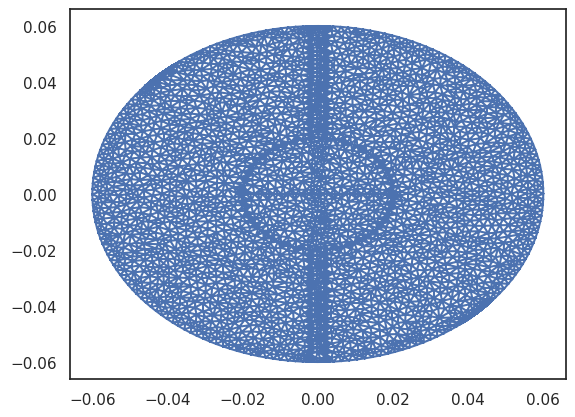

In [38]:
nodes, elements, boundary_edge, boundary_inidces, boundary_elements, outer_curve, inner_curve = mt.LoadTriMesh("Netz_SS25.npz", show=True)

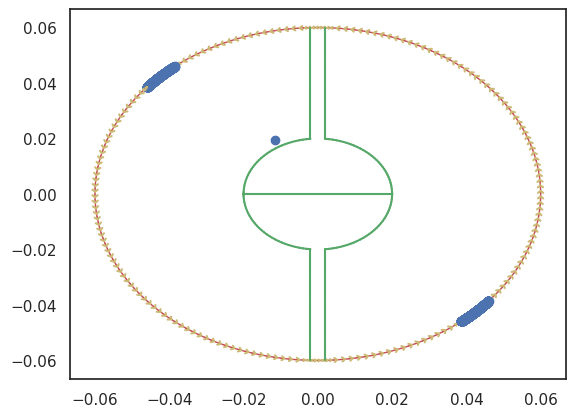

In [39]:
# Vordefinierte Punkte
dalpha=10
angles=np.array([-90, -45-dalpha/2, -45+dalpha/2, 135-dalpha/2, 135+dalpha/2, 270])*np.pi/180
P3 = [ BS/2 , -np.sqrt(RR**2-(BS/2)**2) ]  #
P4 = [ BS/2 , -np.sqrt(RK**2-(BS/2)**2) ]
P5 = [ BS/2 ,  np.sqrt(RK**2-(BS/2)**2) ]
P6 = [ BS/2 , np.sqrt(RR**2-(BS/2)**2) ]    #
an = np.arctan(2*P5[1]/BS)
P9 = [RR*np.cos(angles[1]),RR*np.sin(angles[1])]
P10 = [RR*np.cos(angles[2]),RR*np.sin(angles[2])]
P11 = [RR*np.cos(angles[3]),RR*np.sin(angles[3])]
P12 = [RR*np.cos(angles[4]),RR*np.sin(angles[4])]
P13= [ -P6[0], P6[1] ]
P14= [ -P5[0], P5[1] ]
P15= [ -RR, 0 ]
P16= [ -P4[0], P4[1] ]
P17= [ -P3[0], P3[1] ]

Ps=[P10,P11,P12,P9,P10]
Ps_types = ['Segments','Nodes','Segments','Nodes']
bseg=mt.RetrieveSegments(nodes,boundary_edge,boundary_inidces,Ps,Ps_types)

#Zeichne Ränder
for i in range(4):
  mt.PlotBoundary(nodes,bseg[i],Ps_types[i])
#Zeichne Innere Linien
mt.PlotBoundary(nodes,outer_curve,' ')
plt.plot(nodes[3291,0],nodes[3291,1],'o')
plt.show()

G0=bseg[1] +bseg[3]
G0=np.sort(G0)
R0=bseg[0]+bseg[2]

DIRICHLET_INDICES = np.array(G0)
ROBIN_INDICES= np.array(R0)

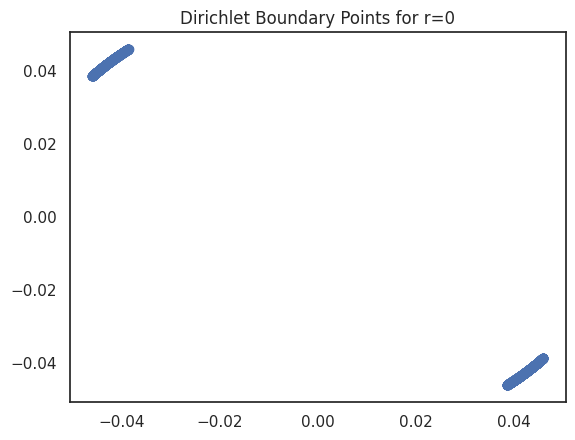

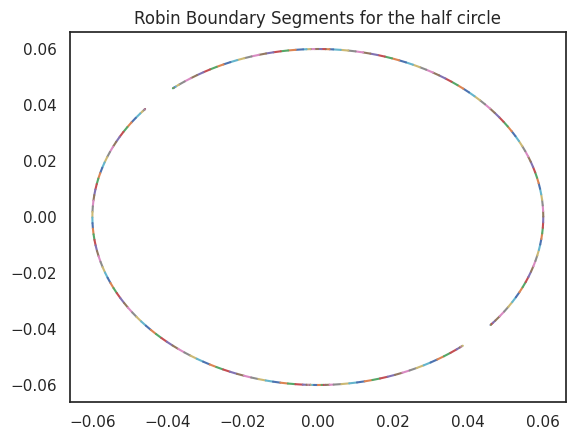

In [40]:
plt.scatter(nodes[DIRICHLET_INDICES][:,0], nodes[DIRICHLET_INDICES][:,1])

plt.title("Dirichlet Boundary Points for r=0")
plt.show()

fig, ax = plt.subplots()
for segment in nodes[ROBIN_INDICES]:
    x_val = [segment[0,0], segment[1,0]]
    y_val = [segment[0,1], segment[1,1]]

    ax.plot(x_val, y_val)

plt.title("Robin Boundary Segments for the half circle")
plt.show()

In [41]:
def dirichlet_func(x, y):

    if x < 0:
        return POTENTIAL_1
    else:
        return POTENTIAL_2



def robin_gamma(x, y):
    return 0

def robin_rhs(x, y):
    return 0

## Solve 2D FEM

In [ ]:
stiffness_matrix, load_vector = myfunc.assemble_global_system(nodes, elements, alpha1, alpha2, beta, rhs)
stiffness_matrix, load_vector = myfunc.insert_robin_values(nodes, stiffness_matrix, load_vector, ROBIN_INDICES, robin_gamma, robin_rhs)
stiffness_matrix, load_vector = myfunc.insert_dirichlet_values(nodes, stiffness_matrix, load_vector, DIRICHLET_INDICES, dirichlet_func)

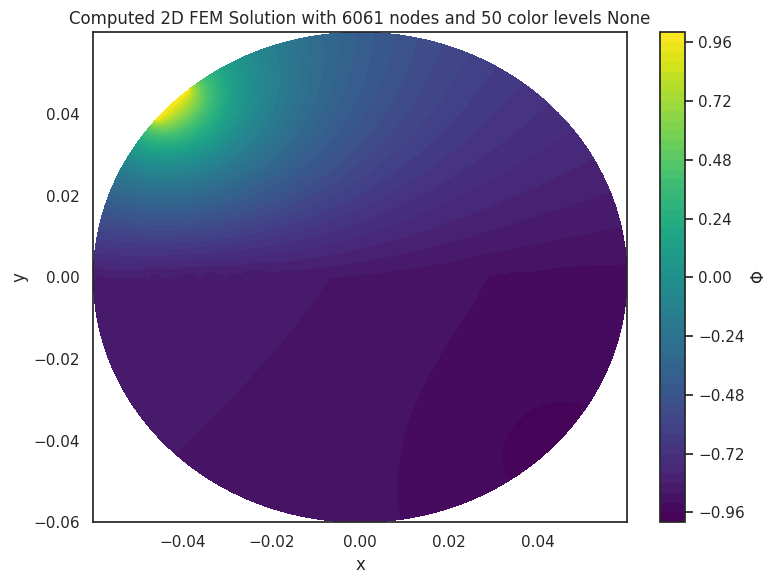

In [ ]:
solution = myfunc.solve_system(nodes, stiffness_matrix, load_vector)
myfunc.plot_result(elements, solution, levels=50)

# fig, axis = plt.subplots(figsize=(8, 6))
# axis.set_xlim(0, 0.125)
# axis.set_ylim(-0.1, 0.1)
# myfunc.plot_result(elements, solution, levels=20, ax=axis, suffix="Zoomed")
# print(solution)

In [ ]:
# check solution
solution["Phi"][329]

np.float64(-1.0)